In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/train_test.csv")

df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [5]:
print("Shape:", df.shape)

df.info()

Shape: (48000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  str    
 1   pickup        48000 non-null  str    
 2   delivery      48000 non-null  str    
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  str    
 9   weight        47700 non-null  float64
 10  date          48000 non-null  str    
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), str(5)
memory usage: 5.1 MB


In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique load_id:", df["load_id"].nunique())
print("Total rows:", len(df))

Duplicate rows: 0
Unique load_id: 48000
Total rows: 48000


In [7]:
df.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [8]:
df[["weight", "market_index", "posted_rate"]].describe()

,weight,market_index,posted_rate
count,47700.000000,47626.000000,48000.000000
mean,31028.844004,1.083387,2373.980682
std,9391.440620,0.168091,1486.493245
min,-47500.000000,0.676390,57.220000
25%,25800.000000,0.949670,1251.555000
50%,31436.500000,1.055800,2030.760000
75%,37018.000000,1.219590,3330.750000
max,47500.000000,1.467780,25533.000000


In [9]:
(df["weight"] < 0).sum()

np.int64(292)

In [10]:
df[df["weight"] < 0]["weight"].describe()

count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64

In [11]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [12]:
df["date"].min(), df["date"].max()

('2025-01-01', '2025-10-31')

In [13]:
df["date"].nunique()

304

In [14]:
df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.month

df["month"].value_counts().sort_index()

month
1     4918
2     4337
3     5036
4     4819
5     4913
6     4783
7     4912
8     4759
9     4670
10    4853
Name: count, dtype: int64

In [15]:
df.groupby("month")["posted_rate"].mean()

month
1     2255.967048
2     2273.804801
3     2372.268092
4     2372.162308
5     2421.776342
6     2497.030115
7     2415.162030
8     2338.407661
9     2406.374013
10    2379.051374
Name: posted_rate, dtype: float64

In [16]:
df[["distance", "weight", "market_index", "quote_signal", "posted_rate"]].corr()

,distance,weight,market_index,quote_signal,posted_rate
distance,1.000000,0.002544,-0.002181,-0.057244,0.908519
weight,0.002544,1.000000,-0.001331,0.008159,0.034840
market_index,-0.002181,-0.001331,1.000000,-0.067827,0.034165
quote_signal,-0.057244,0.008159,-0.067827,1.000000,-0.039858
posted_rate,0.908519,0.034840,0.034165,-0.039858,1.000000


In [17]:
df.select_dtypes(include="number").corr()["posted_rate"].sort_values(ascending=False)


posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
month           0.023804
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64

In [18]:
print("Pickup locations:", df["pickup"].nunique())
print("Delivery locations:", df["delivery"].nunique())
print("Equipment types:", df["equipment"].nunique())

print("\nEquipment values:")
print(df["equipment"].value_counts())

Pickup locations: 64
Delivery locations: 64
Equipment types: 3

Equipment values:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


In [19]:
df.groupby("equipment")["posted_rate"].agg(["count", "mean", "median"])

,count,mean,median
equipment,,,
Dry Van,27202,2271.548686,1953.035
Flatbed,8753,2445.087223,2076.810
Reefer,12045,2553.636939,2196.670


In [20]:
pickup_rates = (
    df.groupby("pickup")["posted_rate"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

pickup_rates.head(10)

,count,mean,median
pickup,,,
San Francisco,453,4071.207108,4301.810
Fresno,827,3878.910000,4160.280
Reno,642,3765.391199,3836.925
Phoenix,1121,3764.774764,3935.620
Los Angeles,945,3729.638392,3996.610
Bakersfield,1193,3519.365448,3804.880
Tucson,944,3310.996271,3535.995
Las Vegas,277,3292.821913,3633.060
Salt Lake City,394,3144.764112,3316.265


In [21]:
delivery_rates = (
    df.groupby("delivery")["posted_rate"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

delivery_rates.head(10)

,count,mean,median
delivery,,,
San Francisco,467,4064.472998,4356.600
Fresno,763,3865.377156,4140.170
Phoenix,1090,3751.473110,3921.980
Los Angeles,955,3742.250932,4046.090
Reno,653,3679.871639,3783.880
Bakersfield,1156,3532.198893,3742.535
Las Vegas,292,3428.375274,3707.765
Tucson,997,3363.189789,3591.790
Salt Lake City,406,3164.350788,3316.060


In [22]:
print("Unique routes:", df[["pickup", "delivery"]].drop_duplicates().shape[0])

Unique routes: 4014


In [23]:
route_counts = (
    df.groupby(["pickup", "delivery"])
      .size()
      .sort_values(ascending=False)
)

route_counts.head(10)

pickup      delivery     
Columbia    Oklahoma City    39
Phoenix     Shreveport       39
Lexington   Atlanta          39
Fort Wayne  Philadelphia     38
Shreveport  Hartford         37
Fort Wayne  Hartford         37
Richmond    Oklahoma City    37
            Phoenix          37
Lexington   Kansas City      37
            Cincinnati       37
dtype: int64

In [24]:
pickup_distance = (
    df.groupby("pickup")["distance"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

pickup_distance.head(10)

,count,mean,median
pickup,,,
San Francisco,453,2087.954084,2220.70
Fresno,827,1959.075091,2157.30
Reno,642,1930.202336,2015.15
Los Angeles,945,1878.908466,2066.30
Phoenix,1121,1874.487779,2024.20
Bakersfield,1193,1770.121961,1961.40
Las Vegas,277,1658.441877,1844.50
Tucson,944,1625.657521,1784.35
Salt Lake City,394,1587.887310,1697.40


In [25]:
df["distance_group"] = pd.cut(
    df["distance"],
    bins=[0, 500, 1000, 1500, 2000, 2500, float("inf")]
)

df.groupby(["distance_group", "pickup"])["posted_rate"].mean()

distance_group  pickup       
(0.0, 500.0]    Albany            919.653864
                Albuquerque       922.194894
                Amarillo         1199.213500
                Atlanta           742.494619
                Austin            730.629123
                                    ...     
(2500.0, inf]   San Francisco    5384.055664
                Savannah         5005.136667
                Syracuse         4923.347170
                Tucson           5246.455304
                Washington       4930.996047
Name: posted_rate, Length: 346, dtype: float64

In [26]:
df["distance_group"].value_counts().sort_index()

distance_group
(0.0, 500.0]        10290
(500.0, 1000.0]     15055
(1000.0, 1500.0]     9008
(1500.0, 2000.0]     6100
(2000.0, 2500.0]     4862
(2500.0, inf]        2685
Name: count, dtype: int64

In [27]:
df["distance_group"] = pd.cut(
    df["distance"],
    bins=[0, 500, 1000, 1500, 2000, 2500, float("inf")]
)

df[df["distance_group"] == pd.Interval(1000, 1500)] \
    .groupby("pickup")["posted_rate"] \
    .agg(["count", "mean", "median"]) \
    .sort_values("count", ascending=False) \
    .head(15)

,count,mean,median
pickup,,,
Oklahoma City,404,2585.721114,2552.880
Amarillo,381,2615.989108,2606.320
San Antonio,358,2626.981536,2558.265
Hartford,314,2448.502898,2322.910
Lubbock,298,2565.287181,2568.600
Baton Rouge,292,2699.290103,2607.840
Shreveport,272,2650.688015,2632.135
Albany,236,2481.757924,2430.300
Corpus Christi,221,2635.149729,2564.430


In [28]:
train_df = df[df["date"] < "2025-09-01"].copy()
val_df = df[df["date"] >= "2025-09-01"].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Train dates:", train_df["date"].min(), "to", train_df["date"].max())
print("Validation dates:", val_df["date"].min(), "to", val_df["date"].max())

Train: (38477, 16)
Validation: (9523, 16)
Train dates: 2025-01-01 00:00:00 to 2025-08-31 00:00:00
Validation dates: 2025-09-01 00:00:00 to 2025-10-31 00:00:00


In [29]:
df["posted_rate"].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

<Axes: >

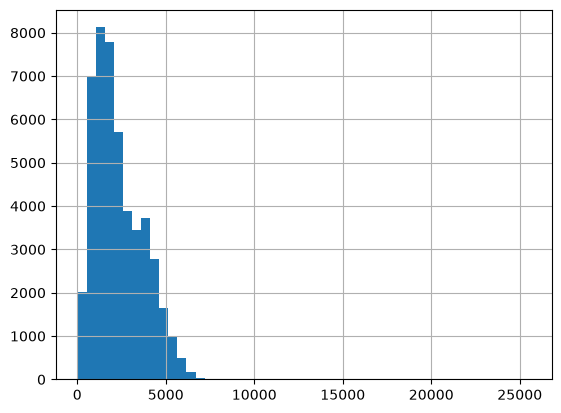

In [30]:
df["posted_rate"].hist(bins=50)

In [31]:
df.loc[df["weight"] < 0, "weight"] = None

In [32]:
df["weight"].isnull().sum()

np.int64(592)

In [33]:
weight_median = train_df["weight"].median()


train_df["weight"] = train_df["weight"].fillna(weight_median)
val_df["weight"] = val_df["weight"].fillna(weight_median)

In [34]:
train_df["date"] = pd.to_datetime(train_df["date"])
val_df["date"] = pd.to_datetime(val_df["date"])

In [35]:
for df_ in [train_df, val_df]:
    df_["year"] = df_["date"].dt.year
    df_["month"] = df_["date"].dt.month
    df_["day"] = df_["date"].dt.day
    df_["day_of_week"] = df_["date"].dt.dayofweek

In [36]:
train_df.drop(columns=["date", "year"], inplace=True)
val_df.drop(columns=["date", "year"], inplace=True)

In [37]:
print("Pickup unique:", train_df["pickup"].nunique())
print("Delivery unique:", train_df["delivery"].nunique())

print("\nPickup examples:")
print(train_df["pickup"].unique()[:20])

print("\nDelivery examples:")
print(train_df["delivery"].unique()[:20])

Pickup unique: 64
Delivery unique: 64

Pickup examples:
<StringArray>
[     'Richmond',  'Philadelphia',      'Hartford',        'Dallas',
       'Phoenix',        'Fresno', 'San Francisco',   'Bakersfield',
   'Albuquerque',    'Harrisburg',        'Mobile',     'Nashville',
       'Detroit',        'Albany',   'New Orleans',          'Reno',
        'Austin',   'Chattanooga',    'Cincinnati',      'Syracuse']
Length: 20, dtype: str

Delivery examples:
<StringArray>
[     'Baltimore',   'Philadelphia',      'Green Bay',        'Atlanta',
      'Nashville', 'Corpus Christi',    'San Antonio',    'Kansas City',
     'Montgomery',        'Phoenix',         'Fresno',      'Lexington',
        'El Paso',       'Syracuse',     'Louisville',    'Baton Rouge',
    'Bakersfield',    'Albuquerque',     'Cincinnati',  'Oklahoma City']
Length: 20, dtype: str


In [38]:
train_df.loc[train_df["weight"] < 0, "weight"] = np.nan
val_df.loc[val_df["weight"] < 0, "weight"] = np.nan

In [39]:
weight_median = train_df["weight"].median()

train_df["weight"] = train_df["weight"].fillna(weight_median)
val_df["weight"] = val_df["weight"].fillna(weight_median)

In [40]:
#compairrr

In [50]:
import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
df = pd.read_csv("data/train_test.csv", parse_dates=["date"])

# -----------------------------
# 1. Basic preprocessing
# -----------------------------

# Negative weights are invalid
df.loc[df["weight"] < 0, "weight"] = np.nan

# Date features
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

# -----------------------------
# 2. Time-based split
# -----------------------------

train_df = df[df["date"] < "2025-09-01"].copy()
val_df = df[df["date"] >= "2025-09-01"].copy()

# Median learned from TRAIN only
weight_median = train_df["weight"].median()

train_df["weight"] = train_df["weight"].fillna(weight_median)
val_df["weight"] = val_df["weight"].fillna(weight_median)

# -----------------------------
# 3. Remove features not used
# -----------------------------

DROP_COLS = [
    "load_id",
    "date",
    "posted_rate",
    "market_index",
    "quote_signal"
]

X_train = train_df.drop(columns=DROP_COLS)
X_val = val_df.drop(columns=DROP_COLS)

y_train = train_df["posted_rate"]
y_val = val_df["posted_rate"]

# -----------------------------
# 4. One-Hot Encoding
# -----------------------------

X_train = pd.get_dummies(
    X_train,
    columns=["pickup", "delivery", "equipment"],
    dtype=int
)

X_val = pd.get_dummies(
    X_val,
    columns=["pickup", "delivery", "equipment"],
    dtype=int
)

# Make sure validation has exactly the same columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

# -----------------------------
# 5. Ridge
# -----------------------------

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

pred = ridge.predict(X_val)

mae = mean_absolute_error(y_val, pred)
rmse = np.sqrt(mean_squared_error(y_val, pred))

print(f"Ridge MAE: {mae:.2f}")
print(f"Ridge RMSE: {rmse:.2f}")

Ridge MAE: 194.26
Ridge RMSE: 643.99


In [51]:
from catboost import CatBoostRegressor

# -----------------------------
# 1. Prepare categorical data
# -----------------------------

CAT_COLS = ["pickup", "delivery", "equipment"]

X_train_cb = train_df.drop(columns=DROP_COLS).copy()
X_val_cb = val_df.drop(columns=DROP_COLS).copy()

for col in CAT_COLS:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)

# -----------------------------
# 2. CatBoost
# -----------------------------

catboost = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    cat_features=CAT_COLS,
    verbose=False
)

catboost.fit(
    X_train_cb,
    y_train,
    eval_set=(X_val_cb, y_val),
    early_stopping_rounds=50
)

# -----------------------------
# 3. Evaluation
# -----------------------------

pred_cb = catboost.predict(X_val_cb)

mae_cb = mean_absolute_error(y_val, pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_val, pred_cb))

print(f"CatBoost MAE: {mae_cb:.2f}")
print(f"CatBoost RMSE: {rmse_cb:.2f}")

CatBoost MAE: 110.66
CatBoost RMSE: 630.88


In [52]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()

linear.fit(X_train, y_train)

pred_linear = linear.predict(X_val)

mae_linear = mean_absolute_error(y_val, pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_val, pred_linear))

print(f"Linear Regression MAE: {mae_linear:.2f}")
print(f"Linear Regression RMSE: {rmse_linear:.2f}")

Linear Regression MAE: 194.27
Linear Regression RMSE: 643.99
